In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [3]:
f(3.0)

20.0

### Sample polynomial function

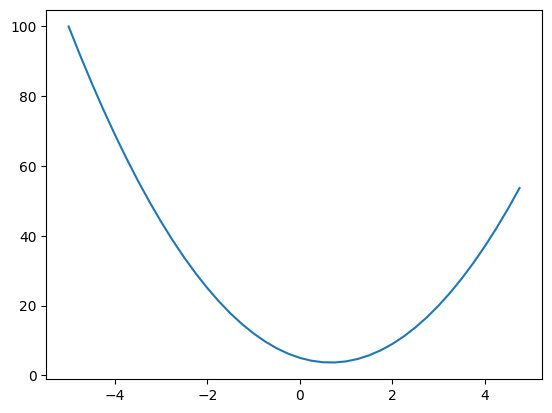

In [4]:
xs = np.arange(-5,5,0.25,)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.00000001
x = 2/3
(f(x+h) - f(x))/h

0.0

In [6]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001
#
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c +=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [8]:
class Value:
    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward

        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data**(other-1))*out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self*other

    def __radd__(self,other):
        return self + other

    def __truediv__(self,other):
        return self*other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,), 'tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
            out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label= 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [9]:
a = Value(2.0)
a.exp()
a-b

Value(data=5.0)

In [10]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [11]:
d._op

'+'

## Visualize the expressions

In [12]:
from graphviz import Digraph
#from micrograd.engine import Value

In [13]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    nodes, edges = trace(root)
    dot = Digraph(format='svg',graph_attr={'rankdir': 'LR'}) #, node_attr={'rankdir': 'TB'})


    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot



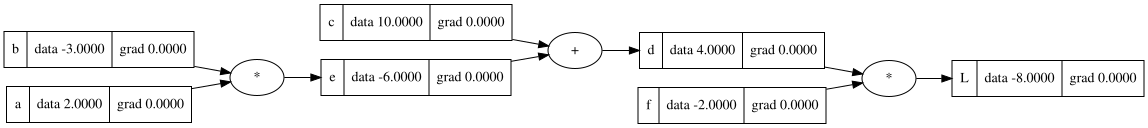

In [14]:
# Output of the forward pass
draw_dot(L)

In [15]:
L.grad = 1.0

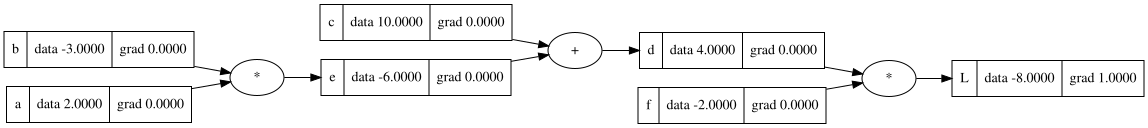

In [16]:
# Output of the forward pass
draw_dot(L)

In [17]:
d.grad = -2.0
f.grad = 4.0

In [18]:
c.grad = -2.0
e.grad = -2.0

In [19]:
a.grad = -2.0*-3.0
b.grad = -2.0*2.0

In [20]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e + c
L = d * f

### MLP

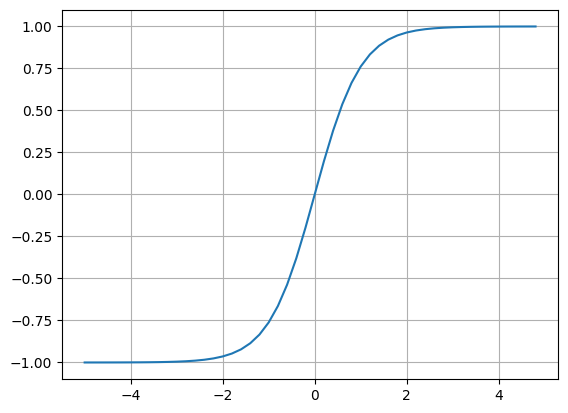

In [21]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

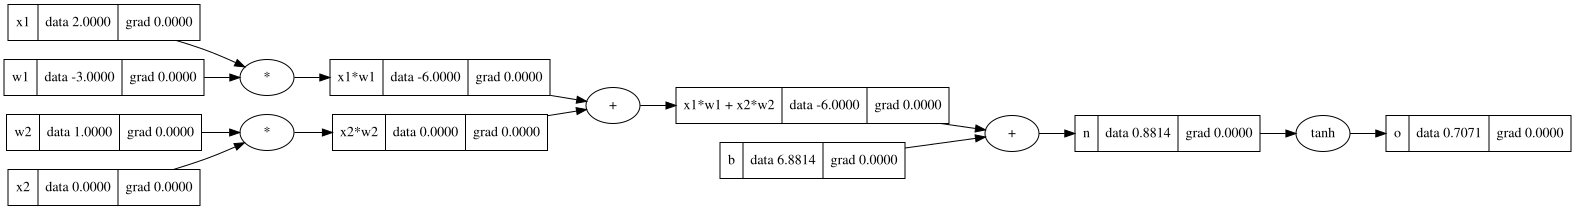

In [22]:
# Inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#Bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

draw_dot(o)

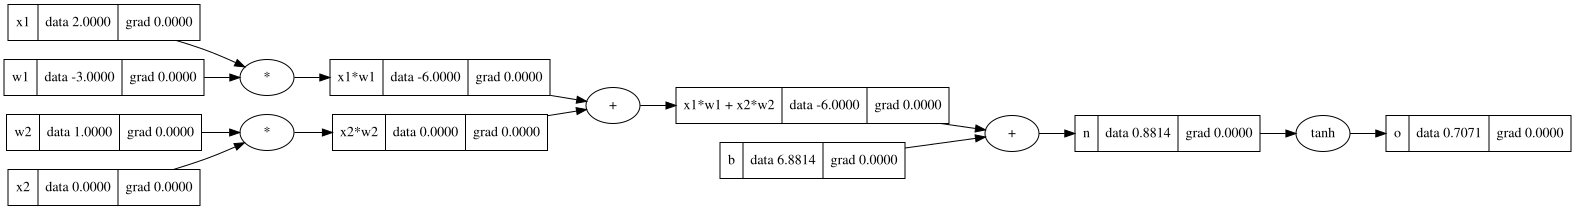

In [23]:
draw_dot(o)

In [24]:
n.grad = 0.5

In [25]:
1 - o.data**2

0.4999999999999999

In [26]:
b.grad = 0.5
x1w1x2w2.grad = 0.5

In [27]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [28]:
x2.grad = w2.data*x2w2.grad
w2.grad = x2.data*x2w2.grad


In [29]:
x1.grad = w1.data*x1w1.grad
w1.grad = x1.data*x1w1.grad

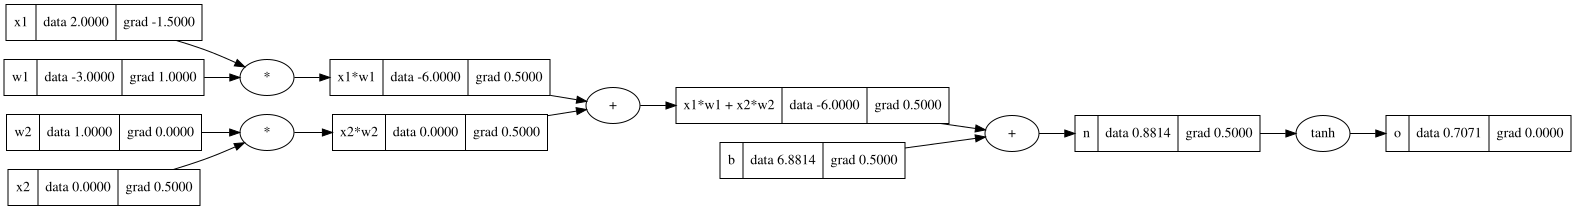

In [30]:
draw_dot(o)

In [31]:
#Base case to set to 1.0
o.grad = 1.0

In [32]:
#Propagate through NL tanh activation function
o._backward()

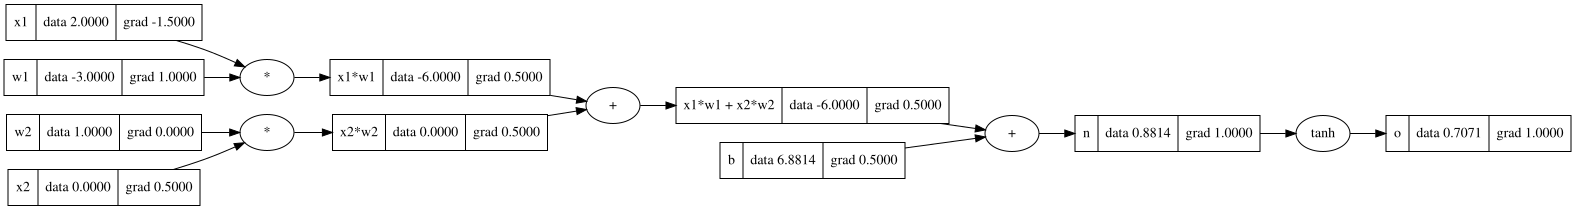

In [33]:
draw_dot(o)

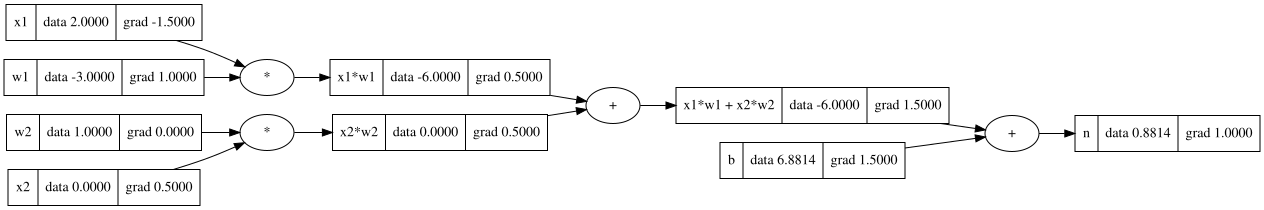

In [34]:
n._backward()
draw_dot(n)

In [35]:
b._backward()

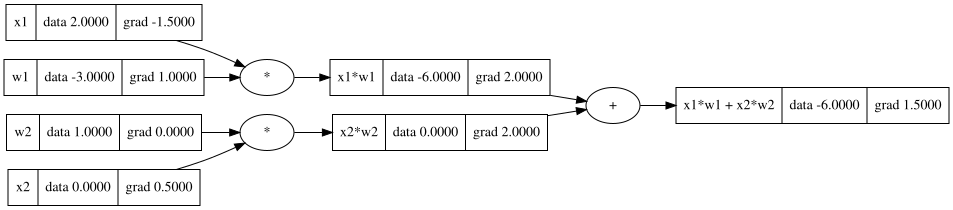

In [36]:
x1w1x2w2._backward()
draw_dot(x1w1x2w2)

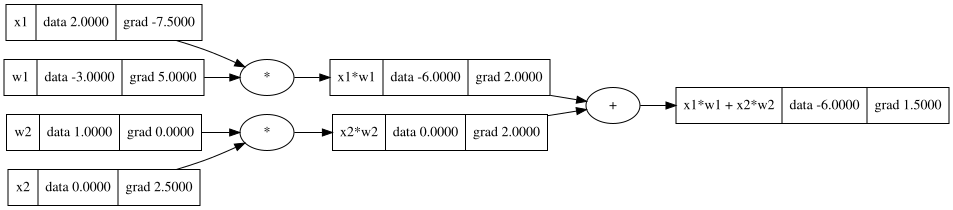

In [37]:
x2w2._backward()
x1w1._backward()

draw_dot(x1w1x2w2)

### To go backward through the expression (expanding) each nodes (Ordering of graph using Topological Sort)

In [38]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

Updated gradients


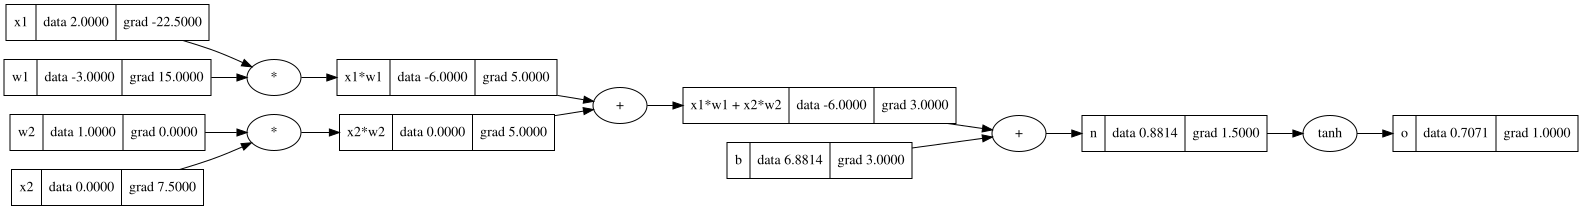

In [39]:
o.grad = 1.0

for node in reversed(topo):
    node._backward()
print('Updated gradients')
draw_dot(o)

### Redefined backward function in the Value class

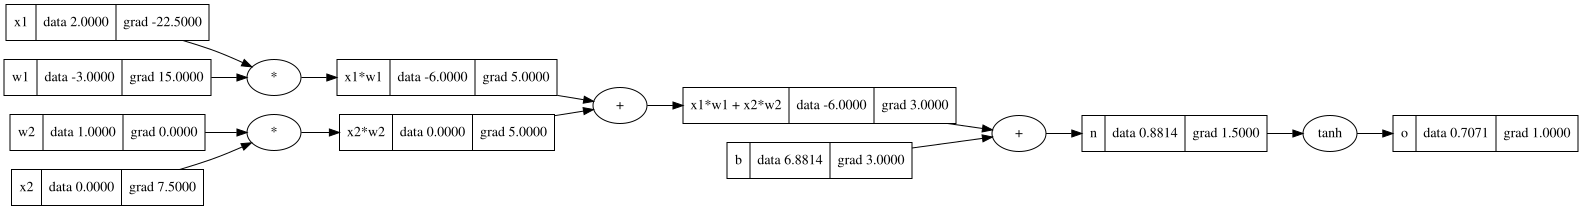

In [40]:
draw_dot(o)

#### For a single Neuron

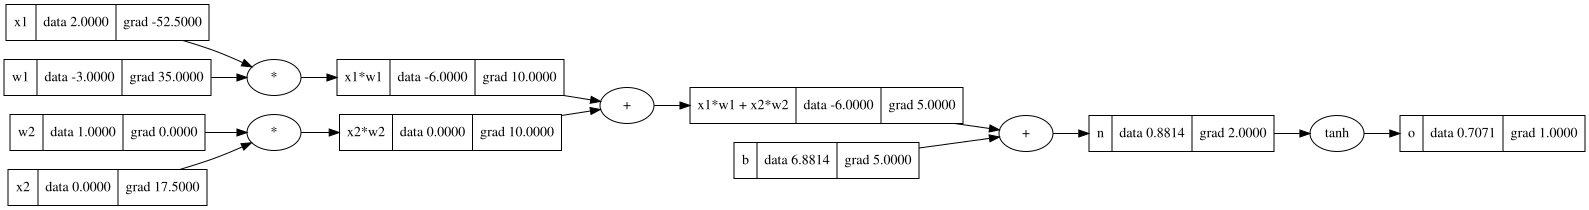

In [41]:
o.backward()
draw_dot(o)

### Solving the bug in BP

#### Instead of overwriting the gradients, Accumulate the gradients

### Neuron

In [42]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for i in range (nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for i in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [43]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.07317925010740454)

In [44]:
### Total no. of parameters in the network
len(n.parameters())
#draw_dot(n(x))

41

### Prediction before learning

In [45]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
# Prediction
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [n(x) for x in xs]
ypred

[Value(data=-0.07317925010740454),
 Value(data=-0.43647913022849305),
 Value(data=-0.5599639919181991),
 Value(data=-0.4164639017362791)]

In [46]:
#MSE
ypred = [n(x) for x in xs]
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss
# minimize loss below certain threshold epsilon

Value(data=3.669271146859657)

### Loss

In [47]:
for k in range(20):

    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad=0

    loss.backward()

    # Initialize the grad to zero
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(f"{k}: Loss: ", loss.data)

0: Loss:  3.669271146859657
1: Loss:  4.666654455311331
2: Loss:  3.24410877346291
3: Loss:  1.2431671484481437
4: Loss:  0.25723526597858515
5: Loss:  0.07006007434917724
6: Loss:  0.0495922915660567
7: Loss:  0.039240071129709606
8: Loss:  0.032885213615752265
9: Loss:  0.028553162488172766
10: Loss:  0.025393398821238884
11: Loss:  0.022975570039265536
12: Loss:  0.0210576846121078
13: Loss:  0.019493010582625342
14: Loss:  0.018187361653131767
15: Loss:  0.017077511475145035
16: Loss:  0.016119448314353975
17: Loss:  0.015281598628327465
18: Loss:  0.014540726605375226
19: Loss:  0.013879352731755997


In [48]:
ypred

[Value(data=0.9197309266274811),
 Value(data=-0.9379067970367296),
 Value(data=-0.990135739808437),
 Value(data=0.9409800109428302)]

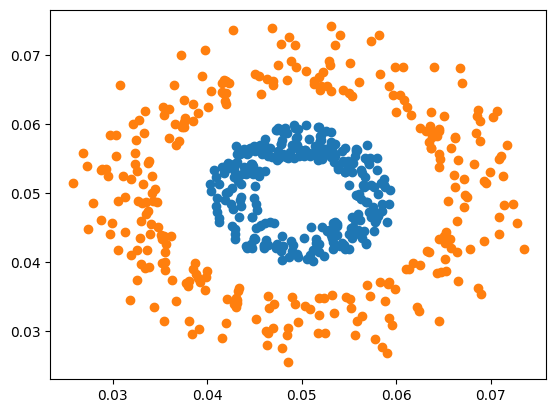

In [49]:
# Generating 1000 data points
np.random.seed(1024)
mu = [5.,5.]
cv= np.diag([1.0,1.0])
DP = 1000
cx1, cy1 = np.random.multivariate_normal(mu, cv, DP).T
rdata = np.column_stack((cx1,cy1))
c1x = []; c1y = []; c2x = []; c2y = []

for i in range(DP):
    if 0.5<np.sqrt((cx1[i]-mu[0])**2 + (cy1[i]-mu[1])**2)<=1.0:
        c1x.append(cx1[i])
        c1y.append(cy1[i])
    if 1.5<np.sqrt((cx1[i]-mu[0])**2 + (cy1[i]-mu[1])**2)<=2.5:
        c2x.append(cx1[i])
        c2y.append(cy1[i])

c1_data = np.column_stack((c1x,c1y,np.zeros(len(c1x))))/100
c2_data = np.column_stack((c2x,c2y, np.ones(len(c2x))))/100

data_train = np.concatenate((c1_data, c2_data))

X = data_train[:,0:2]
y = data_train[:,2]

plt.scatter(c1_data[:,0],c1_data[:,1])
plt.scatter(c2_data[:,0],c2_data[:,1])
plt.show()

### Small Size MLP

In [51]:
# Size of MLP
n = MLP(2,[4,4,1])
ypred = [n(x) for x in X]
#print(ypred)

#No. of parameters
#print("No. of params: ",len(n.parameters()))

for k in range(50):

    ypred = [n(x) for x in X]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(y, ypred))

    for p in n.parameters():
        p.grad=0

    loss.backward()

    learning_rate = 0.001

    # Initialize the grad to zero
    for p in n.parameters():
        p.data += -learning_rate * p.grad

    print(f"{k}: Loss: ", loss.data)

0: Loss:  324.5625312850603
1: Loss:  196.23173530326656
2: Loss:  250.3360667091171
3: Loss:  134.8618792800359
4: Loss:  179.93525455647074
5: Loss:  113.08514278223237
6: Loss:  128.50950291195988
7: Loss:  93.07194239491857
8: Loss:  91.00480995455597
9: Loss:  66.66131777510473
10: Loss:  59.41462744238947
11: Loss:  42.18807523789298
12: Loss:  34.803159608435585
13: Loss:  23.943819642095676
14: Loss:  18.592596234448187
15: Loss:  12.581374683733998
16: Loss:  9.365747616969195
17: Loss:  6.315454828026287
18: Loss:  4.5756855957627405
19: Loss:  3.09494791209072
20: Loss:  2.2060289685796635
21: Loss:  1.5007776998435964
22: Loss:  1.0604699064601684
23: Loss:  0.7268599564710818
24: Loss:  0.5124563312087015
25: Loss:  0.3548966394776244
26: Loss:  0.25149891222870524
27: Loss:  0.17705517062093912
28: Loss:  0.12747189993747374
29: Loss:  0.0922640219728396
30: Loss:  0.0685681355602901
31: Loss:  0.05189992301907027
32: Loss:  0.04059983977805405
33: Loss:  0.03270203975699

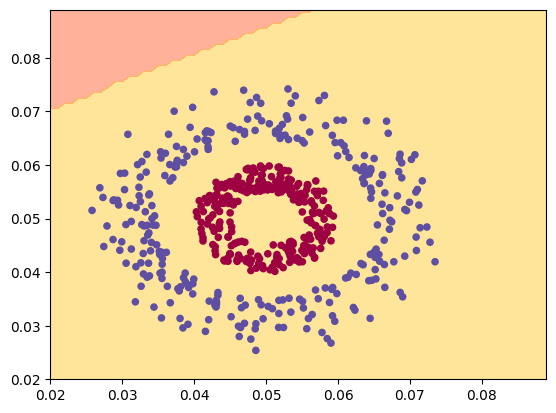

In [52]:
# visualize decision boundary

h = 0.001
#x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
#y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

x_min, x_max = 0.02, 0.09
y_min, y_max = 0.02, 0.09
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(n, inputs))
Z = np.array([s.data > 0.0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.autumn, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()